
# Explore ABMIL Slide Embeddings (UMAP + Silhouette)

This notebook:
- Shows the **dimension** of the first embedding file found.
- Loads **train/val/test** encodings and their **ISUP** labels (from your CSVs).
- Computes a **2D UMAP** projection (falls back to **t-SNE** or **PCA** if UMAP isn't installed).
- Plots the projection colored by ISUP, and prints the **silhouette coefficient**.


In [8]:

from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# 🔧 CONFIG: Set these paths
# -----------------------
# Base directory that contains subfolders: 'train', 'val', 'test' with .npy encodings
# EMBED_ROOT = Path("/Users/emma/Desktop/QUEENS/THESIS/contrastive/histopathology_model/MIL-Lab/results/default_512D/embeddings_512")
# EMBED_ROOT = Path("/Users/emma/Desktop/QUEENS/THESIS/contrastive/histopathology_model/MIL-Lab/results/projected_128D/embeddings_128")
EMBED_ROOT = Path("/Users/emma/Desktop/QUEENS/THESIS/contrastive/histopathology_model/MIL-Lab/results/projected_768D_old/embeddings_768")
# Directory containing train.csv, val.csv, test.csv with columns: FILENAME, isup_grade
SPLITS_ROOT = Path("/Users/emma/Desktop/QUEENS/THESIS/contrastive/histopathology_model/MIL-Lab/panda_splits")

# Filename suffix for your saved encodings; change to '_abmil1024.npy' if needed
FILE_SUFFIX = "_abmil768.npy"

# Which splits to visualize: any subset of ['train', 'val', 'test'] or use ['train','val','test']
SELECT_SPLITS = ['val']  # or e.g., ['train'] or ['train','val']

# Random seed for reproducibility of projections
RANDOM_STATE = 42



## Helpers


In [9]:

def list_embedding_files(split_dir: Path, file_suffix: str):
    """Return list of Path objects to .npy files in split_dir that end with file_suffix.
    If none match the suffix, fall back to all .npy files.
    """
    files = sorted([p for p in split_dir.glob("*.npy") if p.name.endswith(file_suffix)])
    if len(files) == 0:
        files = sorted(split_dir.glob("*.npy"))
    return files

def first_embedding_shape(emb_root: Path, select_splits, file_suffix: str):
    for split in select_splits:
        split_dir = emb_root / split
        if split_dir.is_dir():
            files = list_embedding_files(split_dir, file_suffix)
            if len(files) > 0:
                arr = np.load(files[0])
                return files[0], arr.shape, split
    return None, None, None

def load_split_csv(splits_root: Path, split: str) -> pd.DataFrame:
    """Load split CSV. Expected columns: FILENAME, isup_grade."""
    path = splits_root / f"{split}.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing CSV for split '{split}': {path}")
    df = pd.read_csv(path)
    if 'FILENAME' not in df.columns or 'isup_grade' not in df.columns:
        raise ValueError("CSV must contain columns 'FILENAME' and 'isup_grade'.")
    # coerce label to int
    df['isup_grade'] = df['isup_grade'].astype(int)
    return df

def sid_from_filename(fname: str, file_suffix: str):
    """Strip the suffix like _abmil512.npy -> return the slide id."""
    if fname.endswith(file_suffix):
        return fname[: -len(file_suffix)]
    if fname.endswith('.npy'):
        return fname[:-4]
    return fname

def load_dataset(emb_root: Path, splits_root: Path, splits, file_suffix: str):
    """Return features X (n_samples, D), labels y (n_samples,), and metadata DataFrame with columns [sid, split, isup_grade]."""
    X_list, y_list, rows = [], [], []
    for split in splits:
        split_dir = emb_root / split
        if not split_dir.exists():
            print(f"[warn] Split dir missing: {split_dir}")
            continue
        csv = load_split_csv(splits_root, split)
        # map sid -> label
        sid_to_label = dict(zip(csv['FILENAME'].astype(str), csv['isup_grade'].astype(int)))
        # iterate files
        files = list_embedding_files(split_dir, file_suffix)
        for f in files:
            sid = sid_from_filename(f.stem, file_suffix.replace('.npy',''))
            # If your saved sid exactly equals FILENAME from CSV, this matches directly.
            # If not, adapt this mapping as needed.
            if sid not in sid_to_label:
                # try exact stem if suffix handling differed
                if f.stem in sid_to_label:
                    sid = f.stem
                else:
                    # skip if no label
                    continue
            x = np.load(f)
            X_list.append(x.reshape(-1))  # ensure 1D
            y_list.append(sid_to_label[sid])
            rows.append({'sid': sid, 'split': split, 'isup_grade': sid_to_label[sid], 'path': str(f)})
    if len(X_list) == 0:
        raise RuntimeError("No embeddings found. Check EMBED_ROOT, splits, and FILE_SUFFIX.")
    X = np.vstack(X_list)
    y = np.array(y_list, dtype=int)
    meta = pd.DataFrame(rows)
    return X, y, meta

def try_project_2d(X, random_state=42):
    """UMAP -> TSNE -> PCA fallback. Returns (Z, method_name)."""
    # Try UMAP
    try:
        import umap.umap_ as umap
        reducer = umap.UMAP(n_components=2, random_state=random_state)
        Z = reducer.fit_transform(X)
        return Z, "UMAP"
    except Exception as e:
        print(f"UMAP unavailable or failed ({e}). Trying t-SNE...")
    # Try t-SNE
    try:
        from sklearn.manifold import TSNE
        Z = TSNE(n_components=2, random_state=random_state, init='pca', learning_rate='auto').fit_transform(X)
        return Z, "TSNE"
    except Exception as e:
        print(f"TSNE failed ({e}). Falling back to PCA...")
    # PCA fallback
    from sklearn.decomposition import PCA
    Z = PCA(n_components=2, random_state=random_state).fit_transform(X)
    return Z, "PCA"

def plot_embedding(Z, meta: pd.DataFrame, title: str = "2D Projection", annotate=False):
    """Scatter plot of Z colored by ISUP. One chart, default colors."""
    fig = plt.figure(figsize=(7,5))
    # color by ISUP grade
    grades = sorted(meta['isup_grade'].unique().tolist())
    for g in grades:
        idx = (meta['isup_grade'] == g).values
        plt.scatter(Z[idx, 0], Z[idx, 1], label=f"ISUP {g}", s=10)
    plt.legend(title="ISUP")
    plt.title(title)
    plt.xlabel("dim-1"); plt.ylabel("dim-2")
    plt.show()

def silhouette_or_nan(Z, labels):
    """Compute silhouette score; return NaN if it cannot be computed (e.g., 1 class or degenerate)."""
    from sklearn.metrics import silhouette_score
    # Need at least 2 labels and at least 2 samples in total
    if len(set(labels)) < 2 or len(labels) < 3:
        return float('nan')
    try:
        return float(silhouette_score(Z, labels))
    except Exception:
        return float('nan')



## Inspect the first embedding file
This helps confirm the vector dimension (e.g., **512** for ABMIL512 or **1024** if you used a custom head).


In [10]:

first_path, first_shape, first_split = first_embedding_shape(EMBED_ROOT, SELECT_SPLITS, FILE_SUFFIX)
if first_path is None:
    raise RuntimeError("No .npy files found. Check EMBED_ROOT and FILE_SUFFIX.")
print(f"First file: {first_path}")
print(f"Split: {first_split}")
print(f"Shape: {first_shape}  -> Embedding dim = {first_shape[-1]} if shape is (D,) or second dim if (N,D)")

First file: /Users/emma/Desktop/QUEENS/THESIS/contrastive/histopathology_model/MIL-Lab/results/projected_768D_old/embeddings_768/val/01b3d1fe5b0bd538d1e9824fe7d2d24d_abmil768.npy
Split: val
Shape: (768,)  -> Embedding dim = 768 if shape is (D,) or second dim if (N,D)



## Load embeddings and labels
Merges **train/val/test** according to `SELECT_SPLITS`, then stacks all vectors.


In [11]:

X, y, meta = load_dataset(EMBED_ROOT, SPLITS_ROOT, SELECT_SPLITS, FILE_SUFFIX)
print(f"Loaded: X={X.shape}, y={y.shape}")
display(meta.groupby(['split','isup_grade']).size().rename('count').reset_index())


Loaded: X=(954, 768), y=(954,)


,split,isup_grade,count
0,val,0,260
1,val,1,240
2,val,2,121
3,val,3,111
4,val,4,112
5,val,5,110



## 2D Projection and Silhouette
We first attempt **UMAP**, falling back to **t-SNE** and then **PCA** if needed.
Silhouette coefficient is computed on the 2D embedding (note: it is typically higher in the original feature space).


/opt/anaconda3/envs/picai/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Projection method: UMAP


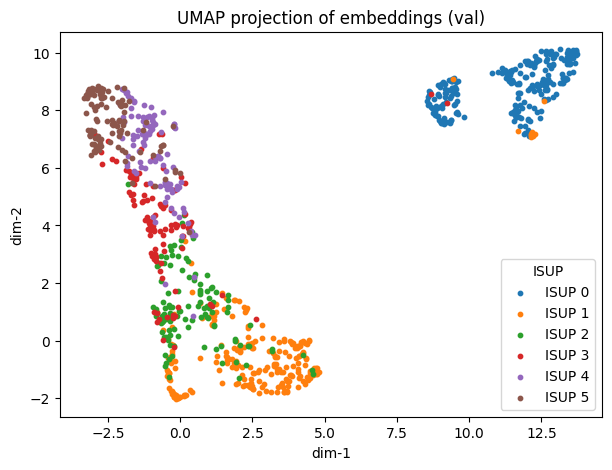

Silhouette coefficient (on 2D UMAP): 0.31034696102142334


In [12]:

Z, method = try_project_2d(X, random_state=RANDOM_STATE)
print(f"Projection method: {method}")
plot_embedding(Z, meta, title=f"{method} projection of embeddings ({', '.join(SELECT_SPLITS)})")

from sklearn.metrics import silhouette_score
sil = silhouette_or_nan(Z, y)
print(f"Silhouette coefficient (on 2D {method}): {sil}")

In [13]:
print(X.shape)

(954, 768)


In [14]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

Xz = StandardScaler().fit_transform(X)
sil_512_cos = silhouette_score(Xz, y, metric="cosine")
sil_512_euc = silhouette_score(Xz, y, metric="euclidean")
print(f"Silhouette ({X.shape[1]}D, cosine): {sil_512_cos:.3f}  |  (euclidean): {sil_512_euc:.3f}")


Silhouette (768D, cosine): 0.187  |  (euclidean): 0.171
